In [1]:
import pyscf
import pyscf.cc
import pyscf.mcscf

import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from tqdm.notebook import tqdm
import pandas as pd
import os, sys

In [2]:
# for structure in glob("structures/*xyz"):
#     with open(structure,'r') as f:
#         structlines = f.readlines()
#     xyzlines = []    
#     for line in structlines:
#         if 'units'  not in line and 'symmetry'  not in line:
#             split = line.split()
#             if len(split)>1:
#                 xyzlines.append(split)

#     # with open(structure,'w') as g:
#         g.write(f"{len(xyzlines)}\n\n")
#         for a,x,y,z in xyzlines:
#             x,y,z = float(x),float(y),float(z)
#             g.write(f"{a} {x:>13.6f} {y:>13.6f} {z:>13.6f}\n")

In [3]:
basis_sets = ['STO-3G','cc-pVDZ','aug-cc-pVDZ']

In [4]:
active_spaces = pd.read_csv('../DDLUCJ_active_spaces_unfrozen.csv').dropna(axis=1)

In [5]:
active_spaces

,molecule,n_frozen,n_electrons,num_orbitals
0,water,0,10,7
1,ammonia,0,10,8
2,methane,0,10,9
3,formaldehyde,0,16,12
4,ethylene,0,16,14
5,ethane,0,18,16
6,methanol,0,18,14
7,GDB04_53,0,30,26
8,GDB04_49,0,30,26
9,GDB04_33,0,32,26


In [6]:
# All molecules are uncharged and closed-shell
open_shell = False
spin_sq = 0
energies = {}
#Iterate over basis sets
for b in basis_sets:
    energies[b] = {}
    # Iterate over DataFrame rows and find the structures in the directory
    for row in active_spaces.itertuples(index=False):
        structure_dict = row._asdict()
        molname = structure_dict['molecule']
        molfroz = structure_dict['n_frozen']
        molelec = structure_dict['n_electrons']
        molorb = structure_dict['num_orbitals']
        
        if 'GDB' in molname:
            structpath = f"./structures/{molname}.xyz"
        else:
            structpath = glob(f"./structures/{molname}*.xyz")[0]
        print(structpath)

        print(b,molname,(molelec,molorb))
        if os.path.exists(structpath) and molelec<20:
            print(molname)
    
                        
            # Build N2 molecule
            mol = pyscf.gto.Mole()
            mol.build(
                atom=structpath,
                basis=b
            )
            
            
            # RHF
            scf = pyscf.scf.RHF(mol).run()
            RHF_energy = scf.e_tot
            # CCSD
            ccsd = pyscf.cc.CCSD(scf, frozen=molfroz).run()   
            CCSD_energy = ccsd.run().e_tot    
            # CASCI
            cas = pyscf.mcscf.CASCI(scf, molorb, molelec)
            CASCI_energy = cas.run().e_tot
            

    
            
            print(RHF_energy)
            print(CCSD_energy)
            print(CASCI_energy)

            energies[b][molname] = {"HF":RHF_energy,"CCSD":CCSD_energy,"CASCI":CASCI_energy}

./structures/water183.xyz
STO-3G water (10, 7)
water
converged SCF energy = -74.9605519518539
E(CCSD) = -75.00934953447732  E_corr = -0.04879758262339531
E(CCSD) = -75.00934953447732  E_corr = -0.04879758262339531
CASCI E = -75.0094786655300  E(CI) = -84.1780053937686  S^2 = 0.0000000
-74.96055195185393
-75.00934953447732
-75.00947866552998
./structures/ammonia157.xyz
STO-3G ammonia (10, 8)
ammonia
converged SCF energy = -55.4543178067778
E(CCSD) = -55.51971800028188  E_corr = -0.06540019350406487
E(CCSD) = -55.51971800028188  E_corr = -0.06540019350406487
CASCI E = -55.5199292037949  E(CI) = -67.4646069565729  S^2 = 0.0000000
-55.454317806777816
-55.519718000281884
-55.51992920379487
./structures/methane50.xyz
STO-3G methane (10, 9)
methane
converged SCF energy = -39.7266229997773
E(CCSD) = -39.80592055704319  E_corr = -0.07929755726593053
E(CCSD) = -39.80592055704319  E_corr = -0.07929755726593053
CASCI E = -39.8061565272878  E(CI) = -53.2259210302214  S^2 = 0.0000000
-39.72662299977

In [15]:

# Flatten the dictionary
records = []
for basis_set, molecules in energies.items():
    for molecule, methods in molecules.items():
        for method, energy in methods.items():
            records.append((basis_set, molecule, method, energy))

# Create DataFrame
df = pd.DataFrame(records, columns=['Basis Set', 'Molecule', 'Method', 'Energy'])

# Set MultiIndex
# df.set_index(['Basis Set', 'Molecule', 'Method'], inplace=True)



In [30]:
# df.to_csv('energies.csv')

In [53]:
df = pd.read_csv('energies.csv',index_col=0)
# df.set_index(['Basis Set', 'Molecule','Method'], inplace=True)
# df.loc[:,:,'HF'] = df.loc[:,:,'HF'] - df.loc[:,:,'CASCI']
# df.loc[:,:,'CCSD'] = df.loc[:,:,'CCSD'] - df.loc[:,:,'CASCI']
# df.loc[:,:,'CASCI'] = df.loc[:,:,'CASCI'] - df.loc[:,:,'CASCI']

In [54]:
df

,Basis Set,Molecule,Method,Energy
0,STO-3G,water,HF,-74.960552
1,STO-3G,water,CCSD,-75.009350
2,STO-3G,water,CASCI,-75.009479
3,STO-3G,ammonia,HF,-55.454318
4,STO-3G,ammonia,CCSD,-55.519718
...,...,...,...,...
58,aug-cc-pVDZ,ethane,CCSD,-79.593084
59,aug-cc-pVDZ,ethane,CASCI,-79.237150
60,aug-cc-pVDZ,methanol,HF,-115.061460
61,aug-cc-pVDZ,methanol,CCSD,-115.449369


Energy
Basis Set   Molecule              
STO-3G      water         0.048927
            ammonia       0.065611
            methane       0.079534
            formaldehyde  0.147495
            ethylene      0.163804
            ethane        0.147416
            methanol      0.117850
cc-pVDZ     water         0.005923
            ammonia       0.011120
            methane       0.012995
            formaldehyde  0.041509
            ethylene      0.039498
            ethane        0.026109
            methanol      0.019676
aug-cc-pVDZ water         0.000060
            ammonia       0.000086
            methane       0.000115
            formaldehyde  0.002783
            ethylene      0.002429
            ethane        0.000172
            methanol      0.000119

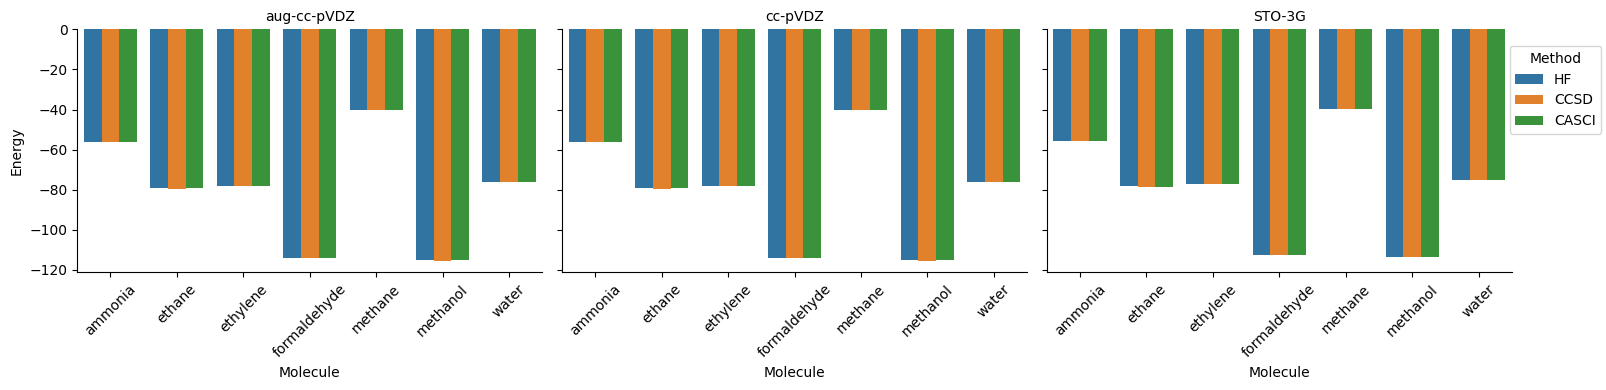

In [28]:
g = sns.catplot(data=df.sort_values(by='Molecule'),    x="Molecule",    y="Energy",    hue="Method",    col="Basis Set",    kind="bar",    height=4,    aspect=1.2)
g.set_titles("{col_name}")
g.set_axis_labels("Molecule", "Energy")

# Move legend outside the plot
g._legend.set_bbox_to_anchor((1.05, 0.75))  # (x, y) position relative to the plot
g._legend.set_frame_on(True)               # Optional: adds a frame around the legend
g.set_xticklabels(rotation=45)
plt.tight_layout()
plt.show()